# Mechanism Across Conditions: Where Do the Differences Live?

Core question (no presupposed conclusion): **different tasks should share learning
mechanisms — so where exactly do the differences live?** This notebook runs two
directions, each driven by an explicit "result -> conclusion" decision table.

Evaluation is **teacher-forced replay on fixed human trajectories** (as in
`main.ipynb`): we characterize the model's conditional policy and its internal
dynamics across conditions. It does **not** measure autonomous task performance
(closed-loop), so claims are limited to "conditional policy / mechanism
differences", not "actual competence".

The condition feature is configurable (`CONDITION_FEATURE`), defaulting to
`visibility`; switching to `n_actions` / `points_type` / `probs_type` /
`block_change_type` is a one-line change.


## 1. Environment & Configuration

Runtime: `iiccsss-rl` (jax + optax + pandas + scipy + matplotlib).


In [ ]:
%load_ext autoreload
%autoreload 2
import os, time, warnings
warnings.filterwarnings("ignore")
# Use the Agg backend in headless settings; keep inline in Jupyter
import matplotlib as _mpl
if "inline" not in _mpl.get_backend().lower() and "agg" not in _mpl.get_backend().lower():
    _mpl.use("Agg")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DataManager import DataManager
import utils

CONFIG = {
    "data_dir": "data/OSF",
    "seed": 0,
    "train_frac": 0.7,
    "val_frac": 0.15,

    # Shared GRU (human data)
    "hidden_size": 32,
    "learning_rate": 1e-3,
    "n_epochs": 32,
    "batch_size": 64,
    "max_gru_sessions": 400,

    # Per-condition models (Direction 2)
    "per_condition_cap": 150,   # max training sessions per condition (balanced)
    "min_test_sessions": 30,    # skip conditions with fewer held-out sessions

    # Analysis
    "max_trials": 60,
    "probe_sessions": 80,
    "n_boot": 2000,

    # Direction-2 visualizations + per-feature scan
    "embed_methods": ["umap", "tsne"],   # merged embeddings for per-condition models
    "n_embed_per_group": 400,            # trials per condition in each embedding
    "feature_scan_cap": 100,             # per-condition training cap in the scan
    "scan_features": ["visibility", "n_actions", "points_type", "probs_type", "block_change_type"],
}

t0 = time.time()
DM = DataManager(data_dir=CONFIG["data_dir"], download_limit=0)
print(f"DataManager loaded in {time.time() - t0:.1f}s")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Local data found with 419 files. Skipping OSF download.
Formatting data for models...


100%|██████████| 419/419 [00:15<00:00, 27.44it/s]


DataManager loaded in 15.3s


In [51]:
# The condition feature used throughout. Change this to "n_actions",
# "points_type", "probs_type" or "block_change_type" to extend the analysis.
CONDITION_FEATURE = "n_actions"

## 2. Design-Level Split & Shared Model

Same convention as `main.ipynb`: split by task **design** (`task_number`) so held-out
designs were never seen during training. The shared GRU is trained on human data
across all train designs.


In [33]:
train_df, val_df, test_df, split_summary = utils.split_task_designs(
    DM, train_frac=CONFIG["train_frac"], val_frac=CONFIG["val_frac"], seed=CONFIG["seed"])
split_summary


,split,n_designs,n_sessions,n_trials
0,train,986,1238,246508
1,val,211,318,63371
2,test,212,534,106156


GRU fit complete. Mean NLL/trial: 0.8423
Shared GRU trained on 400 sessions in 9.8s


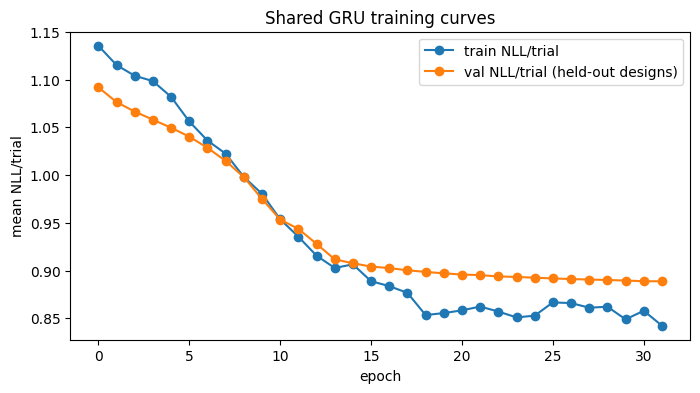

In [34]:
t0 = time.time()
gru_model, gru_used = utils.train_gru(
    train_df, val_df,
    hidden_size=CONFIG["hidden_size"], learning_rate=CONFIG["learning_rate"],
    n_epochs=CONFIG["n_epochs"], batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"], max_sessions=CONFIG["max_gru_sessions"],
)
print(f"Shared GRU trained on {len(gru_used)} sessions in {time.time() - t0:.1f}s")

plt.figure(figsize=(8, 4))
plt.plot(gru_model.loss_history, "-o", label="train NLL/trial")
plt.plot(gru_model.test_loss_history, "-o", label="val NLL/trial (held-out designs)")
plt.xlabel("epoch"); plt.ylabel("mean NLL/trial")
plt.title("Shared GRU training curves"); plt.legend(); plt.show()


## 3. Direction 1 — Where Do the Differences Live?

Three candidate loci, measured on the **shared model** via teacher-forced replay
over held-out sessions:

| Locus | Measure | If significant -> |
|---|---|---|
| Representation (`h_t`) | condition decodability (probe), LDA vs PCA separation, per-unit selectivity | the representation encodes the condition |
| Update dynamics (`z`, `r`) | per-condition gate curves + pairwise curve distances (bootstrap CI) | the update mechanism differs by condition (parametric) |
| Readout (policy) | per-condition NLL / pseudo-R2 and P(best) curves | the policy differs by condition (or data difficulty) |

If **none** of the three show differences, the shared mechanism dominates and
conditions barely matter to the model (discuss why the model fails to reproduce
condition effects).

In [52]:
test_rows = [row for _, row in test_df.iterrows()]
latent_df = utils.collect_latents(gru_model, test_rows)
print("trials x columns:", latent_df.shape)
print("condition values:", sorted(latent_df[CONDITION_FEATURE].dropna().unique()))


trials x columns: (106156, 115)
condition values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### 3.1 Representation — is the condition encoded in `h_t`?

Linear probe (train/val split by session) decoding the condition feature from
`h_t`; `n_actions` / `n_states` are included as control features because the
condition feature is confounded with task structure.

In [53]:
probe_rows = []
for feat in [CONDITION_FEATURE, "n_actions", "n_states"]:
    r = utils.run_feature_probe(latent_df, feat, CONFIG["hidden_size"],
                                seed=CONFIG["seed"], max_sessions=CONFIG["probe_sessions"])
    probe_rows.append({
        "feature": feat,
        "train_acc": round(r["train_acc"], 3),
        "val_acc": round(r["val_acc"], 3),
        "chance": round(1 / r["n_classes"], 3),
        "n_classes": r["n_classes"],
    })
pd.DataFrame(probe_rows)


,feature,train_acc,val_acc,chance,n_classes
0,n_actions,1.000,1.000,0.2,5
1,n_actions,1.000,1.000,0.2,5
2,n_states,0.936,0.869,0.2,5


LDA between/within ratio: 0.322
2-D projection val acc: PCA = 0.483 | LDA = 0.733


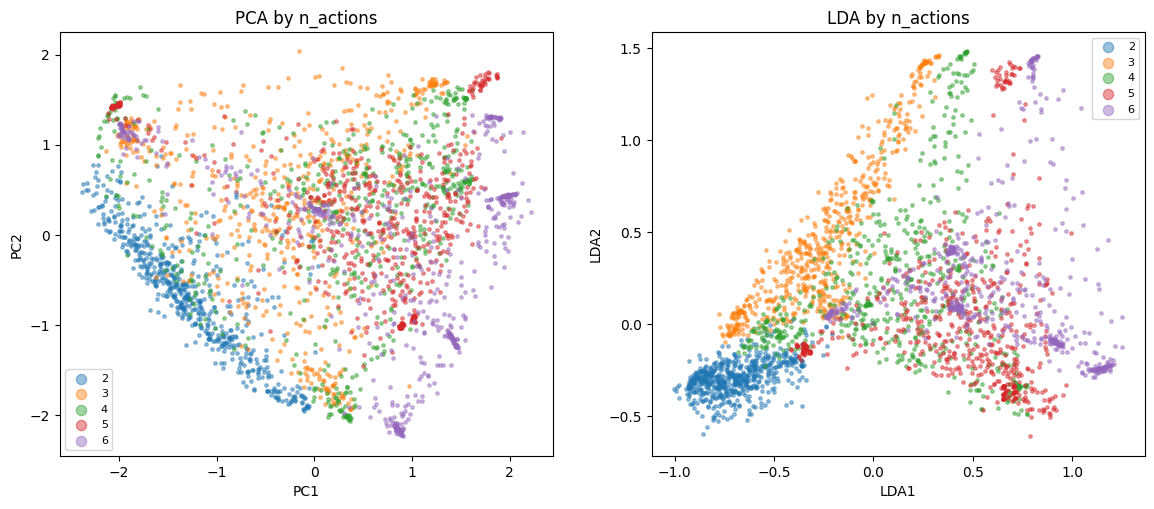

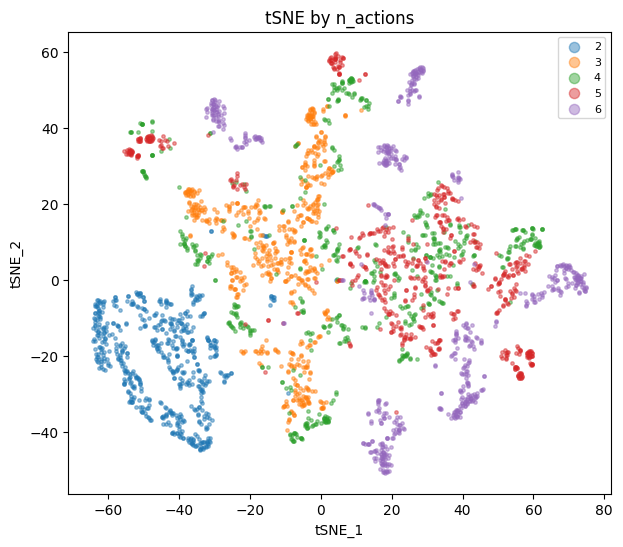

In [54]:
# PCA (total variance) vs LDA (discriminant directions), same balanced subsample
sub = utils.balanced_subset(latent_df, by=CONDITION_FEATURE, n_per_group=600, seed=CONFIG["seed"])
X = sub[utils.hidden_columns(latent_df)].values
y, classes = pd.factorize(sub[CONDITION_FEATURE])

lda = utils.lda_projection(X, y, n_components=2)
pca = utils.pca_scores(X, n_components=2)
tsne = utils.embed_2d(X, method='tsne', seed=CONFIG["seed"])

sub = sub.copy()
sub["PC1"], sub["PC2"] = pca["scores"][:, 0], pca["scores"][:, 1]
sub["LDA1"], sub["LDA2"] = lda["scores"][:, 0], lda["scores"][:, 1]
sub["tSNE_1"], sub["tSNE_2"] = tsne[:, 0], tsne[:, 1]

mask = utils._session_split_mask(sub["session_id"].values, 0.8, CONFIG["seed"])
def proj_val_acc(scores):
    return utils.train_linear_probe(scores[mask], y[mask], scores[~mask], y[~mask],
                                    n_classes=len(classes), seed=CONFIG["seed"])["val_acc"]

print("LDA between/within ratio:", round(lda["between_within_ratio"], 3))
print("2-D projection val acc: PCA =", round(proj_val_acc(pca["scores"]), 3),
      "| LDA =", round(proj_val_acc(lda["scores"]), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
utils.plot_scatter_by_feature(sub, "PC1", "PC2", CONDITION_FEATURE, ax=axes[0],
                              title=f"PCA by {CONDITION_FEATURE}")
utils.plot_scatter_by_feature(sub, "LDA1", "LDA2", CONDITION_FEATURE, ax=axes[1],
                              title=f"LDA by {CONDITION_FEATURE}")
utils.plot_scatter_by_feature(sub, "tSNE_1", "tSNE_2", CONDITION_FEATURE,
                              title=f"tSNE by {CONDITION_FEATURE}")
plt.show()


top-8 selective units: [18, 0, 17, 27, 6, 30, 1, 19]
probe val acc: full hidden = 0.621 | top-8 units = 0.673 (chance 0.25)


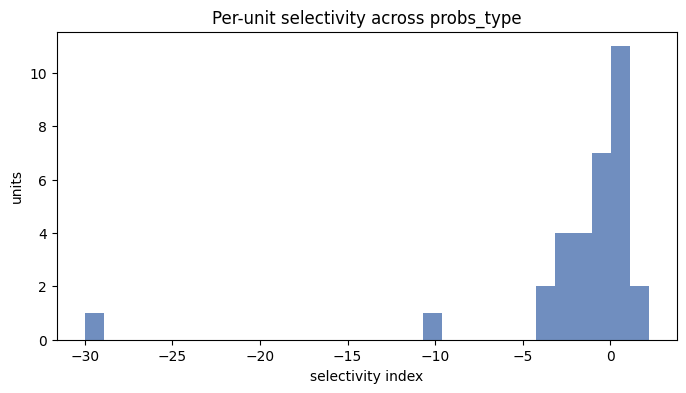

In [38]:
# Per-unit selectivity + top-k decodability (localized vs distributed)
sel = utils.unit_selectivity(X, y)
top = utils.top_k_decodability(latent_df, CONDITION_FEATURE, k=8, seed=CONFIG["seed"],
                               max_sessions=CONFIG["probe_sessions"])
print(f"top-8 selective units: {top['top_units']}")
print(f"probe val acc: full hidden = {probe_rows[0]['val_acc']} | top-8 units = {round(top['val_acc'], 3)} (chance {round(top['chance'], 3)})")

plt.figure(figsize=(8, 4))
plt.hist(sel, bins=30, color="#4C72B0", alpha=0.8)
plt.xlabel("selectivity index"); plt.ylabel("units")
plt.title(f"Per-unit selectivity across {CONDITION_FEATURE}")
plt.show()


### 3.2 Dynamics — do the update/reset gates differ by condition?

Mean gate curves per condition (error bars = SE over sessions), plus pairwise
**gate-curve distances** with bootstrap 95% CIs (resampling sessions). A
significant distance means the update mechanism itself differs.

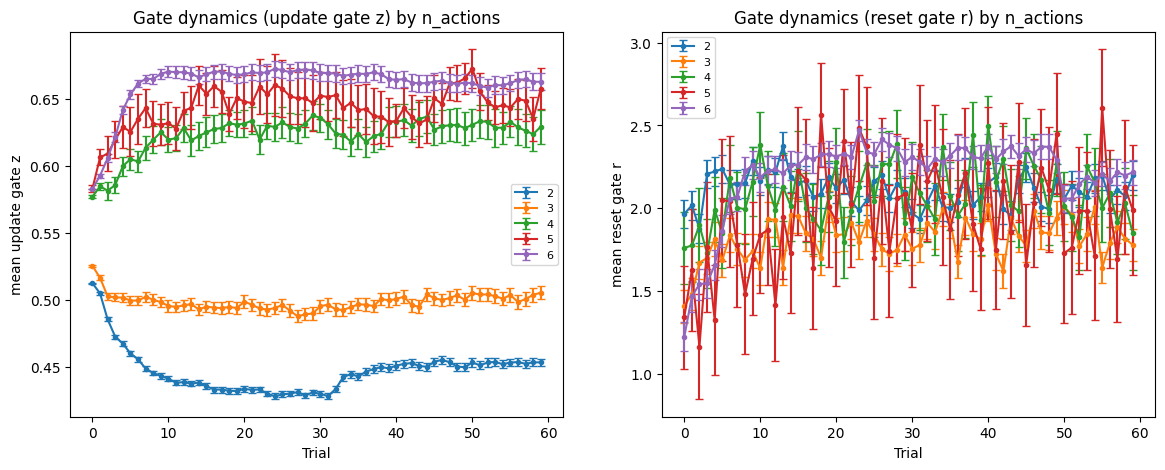

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utils.plot_gate_curves(latent_df, gate="update", feature=CONDITION_FEATURE,
                       max_trials=CONFIG["max_trials"], ax=axes[0])
utils.plot_gate_curves(latent_df, gate="reset", feature=CONDITION_FEATURE,
                       max_trials=CONFIG["max_trials"], ax=axes[1])
plt.show()


In [40]:
for gate, label in [("update", "z"), ("reset", "r")]:
    d = utils.gate_curve_distances_within(
        latent_df, gate=gate, by=CONDITION_FEATURE,
        max_trials=CONFIG["max_trials"], n_boot=CONFIG["n_boot"], seed=CONFIG["seed"])
    d[["distance", "ci_low", "ci_high"]] = d[["distance", "ci_low", "ci_high"]].round(4)
    print(f"gate {label}: pairwise distances (mean |D{label}(t)| over trials, bootstrap 95% CI)")
    print(d.to_string(index=False))
    print()


gate z: pairwise distances (mean |Dz(t)| over trials, bootstrap 95% CI)
                 cond_a                  cond_b  distance  ci_low  ci_high  n_a  n_b
                  all_1       binary_and_stable    0.0989  0.0764   0.1215   36  167
                  all_1 continuous_and_drifting    0.0247  0.0063   0.0489   36   60
                  all_1   continuous_and_stable    0.0372  0.0178   0.0554   36  271
      binary_and_stable continuous_and_drifting    0.1236  0.1058   0.1421  167   60
      binary_and_stable   continuous_and_stable    0.1360  0.1249   0.1480  167  271
continuous_and_drifting   continuous_and_stable    0.0135  0.0092   0.0282   60  271

gate r: pairwise distances (mean |Dr(t)| over trials, bootstrap 95% CI)
                 cond_a                  cond_b  distance  ci_low  ci_high  n_a  n_b
                  all_1       binary_and_stable    0.3361  0.2366   0.4534   36  167
                  all_1 continuous_and_drifting    0.8785  0.7547   1.0092   36   60
     

### 3.3 Readout — do the policies differ by condition?

Per-condition held-out NLL / pseudo-R2 (pseudo-R2 is relative to each session's
chance level) and P(best) adaptation curves.

In [41]:
per_cond = []
for value, grp in test_df.groupby(CONDITION_FEATURE):
    rows = [row for _, row in grp.iterrows()]
    m = utils.evaluate_model_on_sessions(gru_model, rows)
    per_cond.append({"condition": value, "n_sessions": len(rows), **m})
per_cond_df = pd.DataFrame(per_cond).round(4)
per_cond_df


,condition,n_sessions,NLL,n_trials,NLL_per_trial,Pseudo_R2
0,all_1,36,4898.1140,7183,0.6819,0.3310
1,binary_and_stable,167,33113.2672,33212,0.9970,0.3373
2,continuous_and_drifting,60,10380.3024,11970,0.8672,0.1309
3,continuous_and_stable,271,36098.0410,53791,0.6711,0.1285


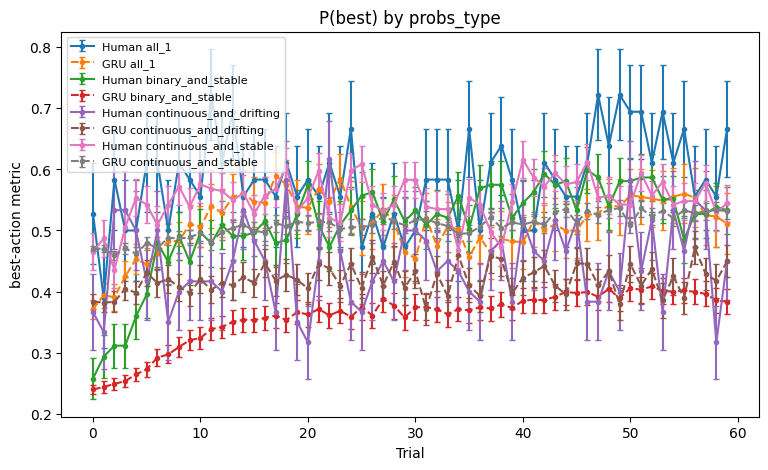

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
for value, grp in test_df.groupby(CONDITION_FEATURE):
    rows = [row for _, row in grp.iterrows()]
    h = utils.pull_average_learning_curve(
        [utils.best_action_curve_from_observed_actions(r, CONFIG["max_trials"]) for r in rows],
        CONFIG["max_trials"])
    g = utils.pull_average_learning_curve(
        [utils.best_action_prob_curve_from_model(gru_model, r, CONFIG["max_trials"]) for r in rows],
        CONFIG["max_trials"])
    x = np.arange(len(h[0]))
    ax.errorbar(x, h[0], yerr=h[1], fmt="-o", ms=3, capsize=2, label=f"Human {value}")
    ax.errorbar(x, g[0], yerr=g[1], fmt="--o", ms=3, capsize=2, label=f"GRU {value}")
ax.set_xlabel("Trial"); ax.set_ylabel("best-action metric")
ax.set_title(f"P(best) by {CONDITION_FEATURE}")
ax.legend(fontsize=8); plt.show()


### Direction 1 — decision table (fill in from the outputs above)

| Observation | Conclusion |
|---|---|
| condition decodable from h (probe/LDA >> chance), even after control | representation layer encodes the condition |
| decodable but ≈ n_actions/n_states control | difference is driven by task structure, not the condition feature itself |
| only gates differ (distances with CI excluding 0) | difference lives in update dynamics (parametric) |
| only NLL / P(best) differ | difference lives in the readout or in data difficulty |
| nothing differs | shared mechanism dominates; conditions barely matter to the model |

## 4. Direction 2 — Shared vs Per-Condition Training

Training a GRU **separately per condition** answers whether the differences found
in Direction 1 are intrinsic to the conditions or an artifact of sharing capacity:

- **(a) Fit cost**: per-condition NLL vs shared-model NLL on the same held-out
  sessions (paired per session, bootstrap CI) — a better per-condition fit means
  the shared model pays a "mixing cost".
- **(b) Dynamics**: gate-curve distances among per-condition models, and between
  each per-condition model and the shared model on the same sessions.
- **(c) Representation alignment**: apply a readout trained on the shared model's
  h to each per-condition model's h (probe transfer), and CCA between the two
  models' h on aligned sessions — high CCA + different gate values => parametric
  difference; low CCA => structural difference.

Per-condition models use the same hyperparameters as the shared model and are
balanced to the smallest condition's training-sample size.
The two shared-model visualizations (merged PCA/t-SNE embedding and gate curves) are also produced for the per-condition models, so cluster clarity and gate dynamics can be compared directly.


In [43]:
# End-to-end Direction-2 report for CONDITION_FEATURE: per-condition training,
# latents, paired fit, gate distances, alignment, and merged embeddings.
cond_report = utils.per_condition_report(
    train_df, val_df, test_df, by=CONDITION_FEATURE, shared_model=gru_model,
    hidden_size=CONFIG["hidden_size"], learning_rate=CONFIG["learning_rate"],
    n_epochs=CONFIG["n_epochs"], batch_size=CONFIG["batch_size"],
    seed=CONFIG["seed"], cap=CONFIG["per_condition_cap"],
    min_test_sessions=CONFIG["min_test_sessions"],
    max_trials=CONFIG["max_trials"], n_boot=CONFIG["n_boot"],
    embed_methods=CONFIG["embed_methods"],
    n_embed_per_group=CONFIG["n_embed_per_group"],
)

info = train_df.groupby(CONDITION_FEATURE).size().rename("train_all").to_frame()
info["train_used"] = [len(cond_report["per_models"][v][1]) for v in cond_report["per_models"]]
info["test_sessions"] = test_df.groupby(CONDITION_FEATURE).size()
info

GRU fit complete. Mean NLL/trial: 0.8185
GRU fit complete. Mean NLL/trial: 0.8173
GRU fit complete. Mean NLL/trial: 0.9911
GRU fit complete. Mean NLL/trial: 0.9131


,train_all,train_used,test_sessions
probs_type,,,
all_1,296,150,36
binary_and_stable,387,150,167
continuous_and_drifting,262,150,60
continuous_and_stable,293,150,271


In [44]:
print("paired NLL (shared - per-condition; >0 => per-condition fits better)")
print(cond_report["paired_nll"].round(4).to_string(index=False))
print("\nper-condition vs shared model, same sessions")
print(cond_report["gate_between"].round(4).to_string(index=False))
for gate, label in [("update", "z"), ("reset", "r")]:
    print(f"\nbetween per-condition models, gate {label}")
    print(cond_report["gate_among"][gate].round(4).to_string(index=False))

paired NLL (shared - per-condition; >0 => per-condition fits better)
              condition  n_test  delta_nll_mean   ci_low  ci_high
                  all_1      36         -4.5819  -7.6160  -2.0966
      binary_and_stable     167        -26.6202 -31.3954 -22.0079
continuous_and_drifting      60         -1.9865  -3.8540  -0.0576
  continuous_and_stable     271         -2.6267  -3.9499  -1.5742

per-condition vs shared model, same sessions
              condition   gate  distance  ci_low  ci_high
                  all_1 update    0.1662  0.1546   0.1781
      binary_and_stable update    0.0611  0.0527   0.0691
continuous_and_drifting update    0.0168  0.0063   0.0292
  continuous_and_stable update    0.0244  0.0205   0.0285
                  all_1  reset    0.0165  0.0138   0.0195
      binary_and_stable  reset    0.0104  0.0085   0.0123
continuous_and_drifting  reset    0.0085  0.0058   0.0113
  continuous_and_stable  reset    0.0141  0.0133   0.0149

between per-condition models, ga

In [45]:
print("probe transfer (readout trained on shared h, applied to per-condition h)")
print(cond_report["probe_transfer"].round(3).to_string(index=False))
print("\nCCA alignment (shared vs per-condition h, same sessions)")
print(cond_report["cca"].round(3).to_string(index=False))

probe transfer (readout trained on shared h, applied to per-condition h)
              condition  shared_train_acc  per_transfer_acc
                  all_1             0.718             0.610
      binary_and_stable             0.741             0.494
continuous_and_drifting             0.574             0.493
  continuous_and_stable             0.638             0.588

CCA alignment (shared vs per-condition h, same sessions)
              condition  cca_top1  cca_mean_top8
                  all_1     0.995          0.962
      binary_and_stable     0.995          0.964
continuous_and_drifting     0.995          0.954
  continuous_and_stable     0.993          0.947


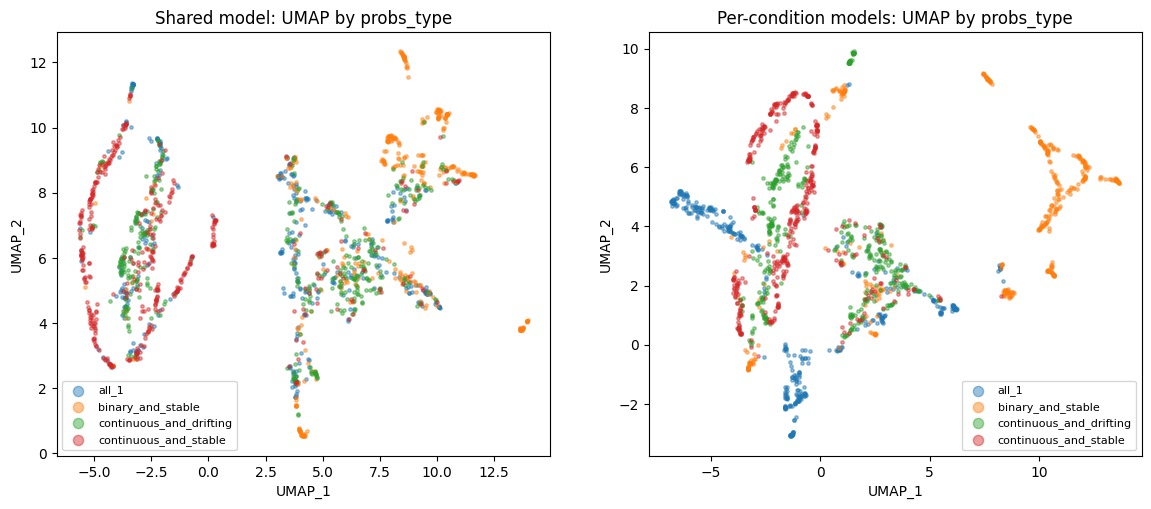

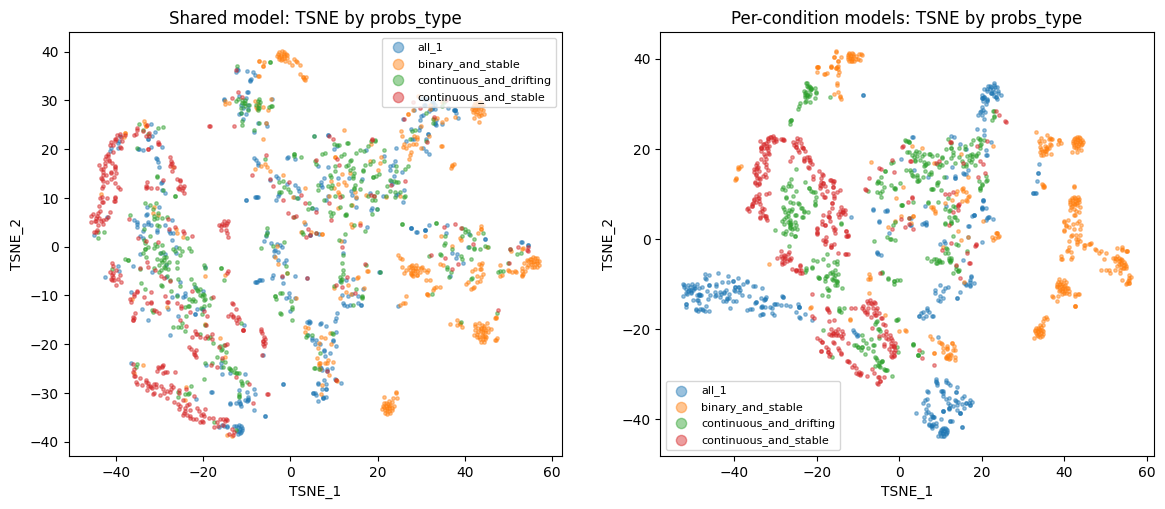

In [46]:
# Merged visualizations: shared model vs per-condition models, same embedding
# (one fit on each panel's pooled h), so cluster clarity can be compared.
for method in CONFIG["embed_methods"]:
    emb = cond_report["embeddings"][method]
    c1 = "PC1" if method == "pca" else f"{method.upper()}_1"
    c2 = "PC2" if method == "pca" else f"{method.upper()}_2"
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    utils.plot_scatter_by_feature(emb["shared"], c1, c2, CONDITION_FEATURE, ax=axes[0],
                                  title=f"Shared model: {method.upper()} by {CONDITION_FEATURE}")
    utils.plot_scatter_by_feature(emb["per"], c1, c2, CONDITION_FEATURE, ax=axes[1],
                                  title=f"Per-condition models: {method.upper()} by {CONDITION_FEATURE}")
    plt.show()

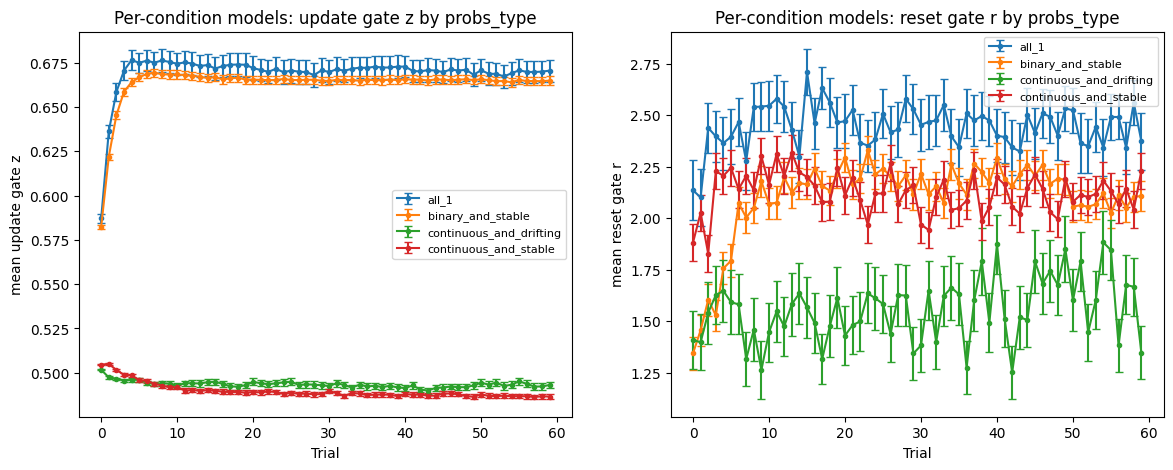

In [47]:
# Gate curves for the per-condition models (mirrors Direction 1's shared panel).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utils.plot_gate_curves(cond_report["lat_per_all"], gate="update",
                       feature=CONDITION_FEATURE, max_trials=CONFIG["max_trials"],
                       title=f"Per-condition models: update gate z by {CONDITION_FEATURE}", ax=axes[0])
utils.plot_gate_curves(cond_report["lat_per_all"], gate="reset",
                       feature=CONDITION_FEATURE, max_trials=CONFIG["max_trials"],
                       title=f"Per-condition models: reset gate r by {CONDITION_FEATURE}", ax=axes[1])
plt.show()

### Direction 2 — decision table (fill in from the outputs above)

| Observation | Conclusion |
|---|---|
| per-condition NLL better (CI > 0) AND dynamics/representation differ | conditions genuinely demand different mechanisms; the shared model pays a real mixing cost |
| per-condition NLL ≈ shared AND CCA high / probe transfers | conditions are compatible; a shared mechanism is sufficient |
| per-condition NLL worse | per-condition training underfits or overfits its smaller sample; interpretation limited (report sample sizes) |
| per-condition models differ from each other in gates | the conditions' optimal dynamics differ intrinsically |
| CCA high but gate values differ | parametric difference (same machinery, different pacing) |
| CCA low | structural difference (different subspaces / dedicated machinery) |

## 5. Summary & TODO

**Main line (this notebook)**

1. Direction 1 localizes condition differences (representation / dynamics /
   readout) on the shared model.
2. Direction 2 tests whether those differences survive separate per-condition
   training (fit cost, dynamics, alignment) and are structural or parametric.

Both directions must be interpreted via their decision tables; no conclusion is
presupposed.

**TODO (out of scope unless the main line is inconclusive)**

- Time-resolved / event-conditioned analysis (early vs steady state vs block
  boundaries)
- Full confound matching (n_actions / n_states) beyond the control probes
- Hidden-dimension sweep ({16, 32, 64} x seeds)
- Closed-loop / ground-truth directions (`main_ground_truth.ipynb`)

## 6. Per-Feature Scan

The same Direction-2 report (per-condition training, merged embeddings, gate
curves, fit/alignment tables) is rerun for every condition feature in
`CONFIG["scan_features"]`. This makes it easy to see which feature produces
clearer clusters / larger gate differences under separate training. Features
with too few held-out sessions are skipped automatically. Runtime scales with
`len(scan_features) x n_conditions x n_epochs`; lower `feature_scan_cap` /
`n_epochs` for a quick pass.

feature: visibility
GRU fit complete. Mean NLL/trial: 0.8893
GRU fit complete. Mean NLL/trial: 0.9453
GRU fit complete. Mean NLL/trial: 0.9039
GRU fit complete. Mean NLL/trial: 0.9664
                      delta_nll  ci_low  ci_high  cca_top8  transfer
condition                                                           
actions                 -52.608 -62.181  -43.105     0.935     0.411
states                  -21.575 -29.397  -14.438     0.954     0.365
states_and_actions      -13.257 -17.207   -9.638     0.945     0.558
states_times_actions    -23.408 -30.911  -16.788     0.955     0.585



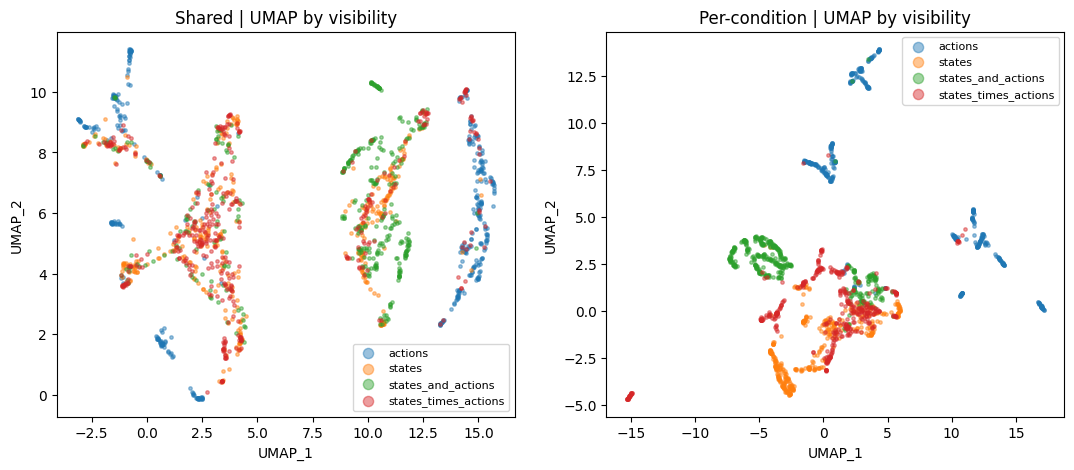

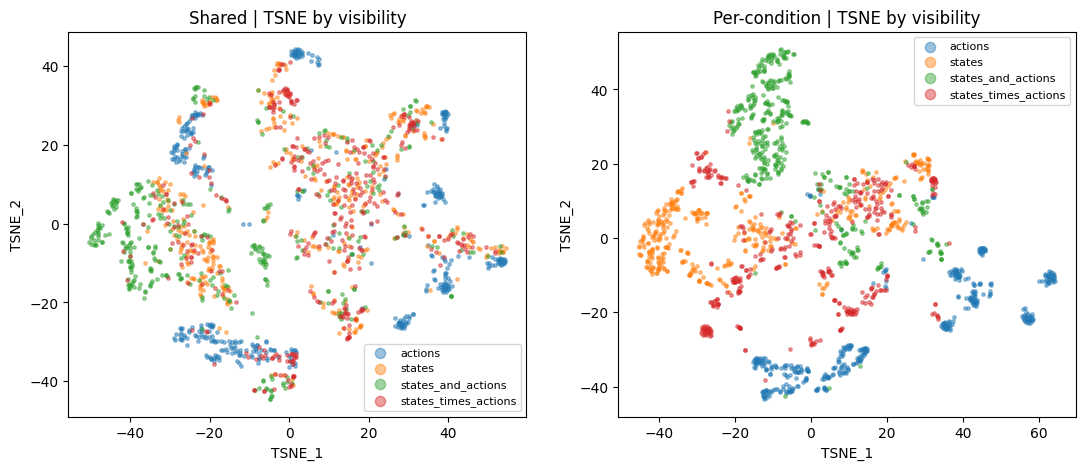

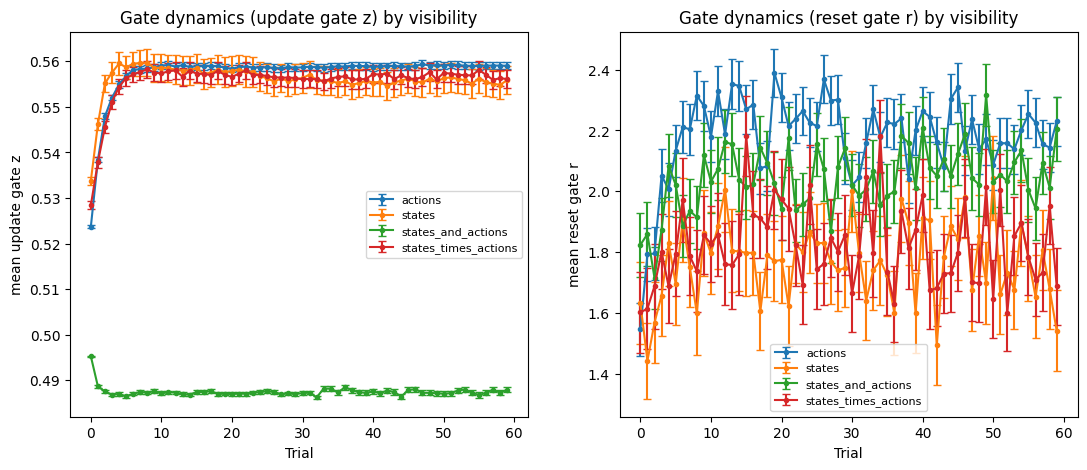

feature: n_actions
GRU fit complete. Mean NLL/trial: 0.6183
GRU fit complete. Mean NLL/trial: 0.9818
GRU fit complete. Mean NLL/trial: 1.1211
GRU fit complete. Mean NLL/trial: 1.5250
GRU fit complete. Mean NLL/trial: 1.4046
           delta_nll   ci_low  ci_high  cca_top8  transfer
condition                                                 
2             -2.072   -2.391   -1.767     0.923     0.522
3            -19.403  -23.945  -15.115     0.948     0.390
4            -31.758  -45.041  -19.520     0.957     0.414
6           -170.634 -189.532 -152.557     0.886     0.191



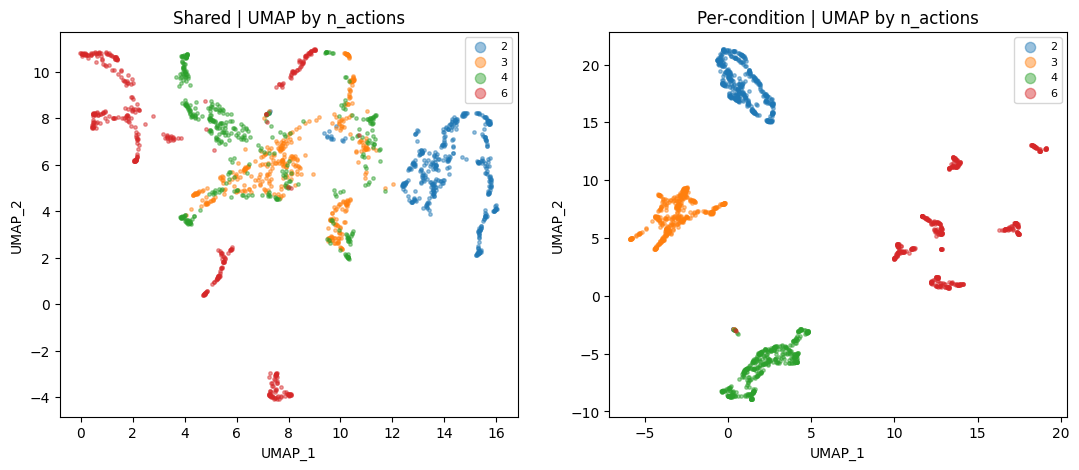

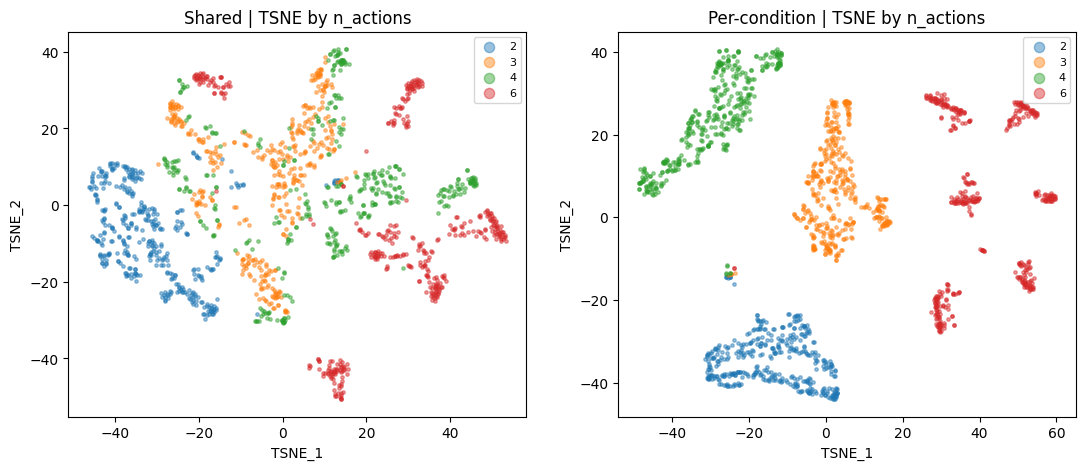

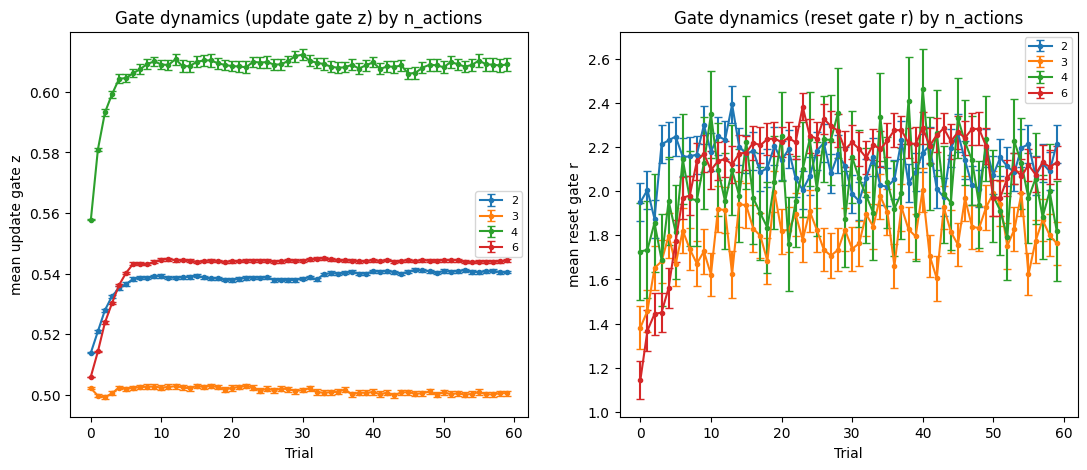

feature: points_type
GRU fit complete. Mean NLL/trial: 0.9610
GRU fit complete. Mean NLL/trial: 0.9533
GRU fit complete. Mean NLL/trial: 0.9479
                         delta_nll  ci_low  ci_high  cca_top8  transfer
condition                                                              
all_1                      -12.480 -15.267   -9.906     0.935     0.551
continuous_and_drifting    -58.886 -68.968  -49.359     0.961     0.302
continuous_and_stable      -18.040 -23.301  -13.083     0.955     0.447



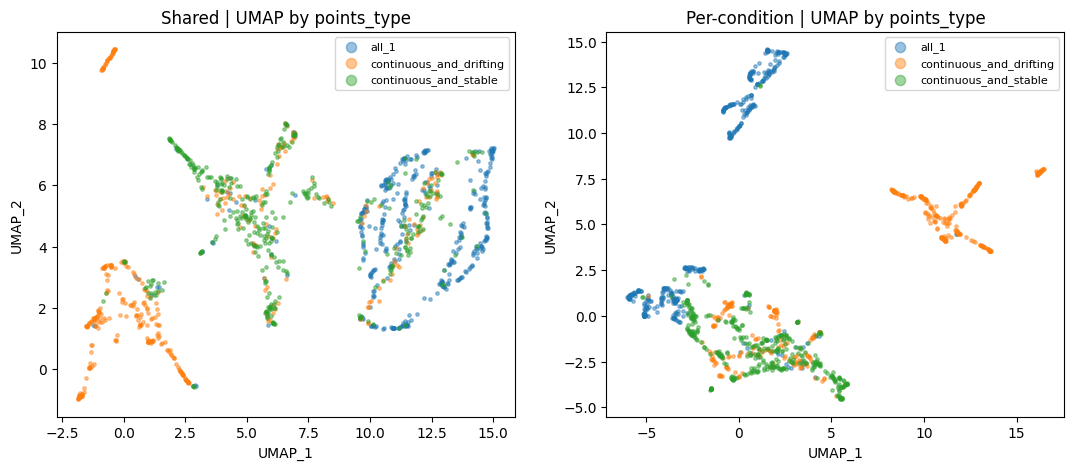

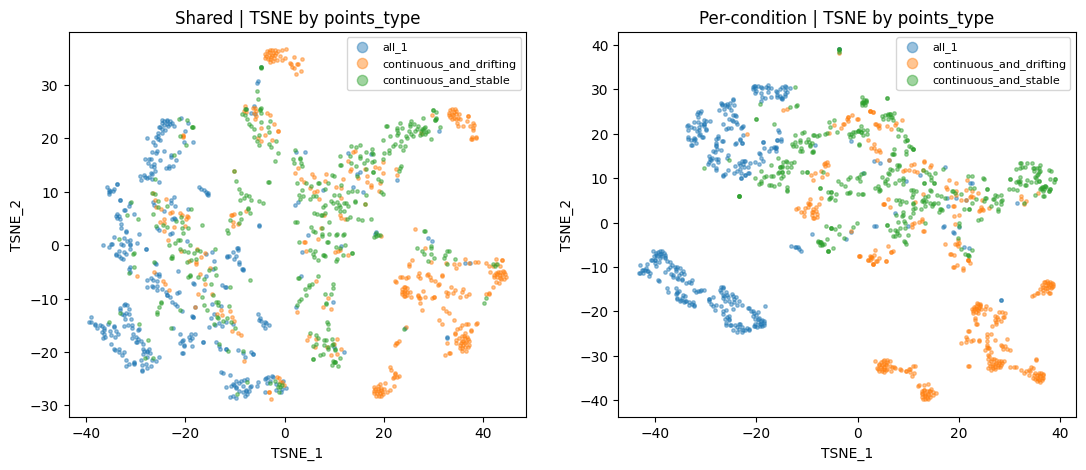

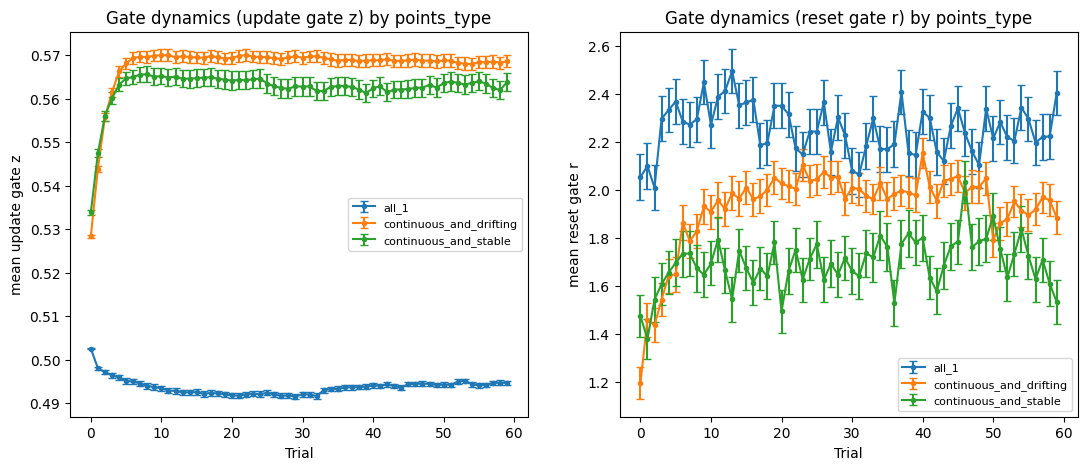

feature: probs_type
GRU fit complete. Mean NLL/trial: 0.9513
GRU fit complete. Mean NLL/trial: 0.9328
GRU fit complete. Mean NLL/trial: 0.9772
GRU fit complete. Mean NLL/trial: 0.9510
                         delta_nll  ci_low  ci_high  cca_top8  transfer
condition                                                              
all_1                      -23.939 -31.050  -17.191     0.957     0.380
binary_and_stable          -74.412 -84.890  -64.632     0.959     0.304
continuous_and_drifting    -12.870 -19.400   -6.573     0.947     0.487
continuous_and_stable       -9.230 -11.856   -6.839     0.937     0.588



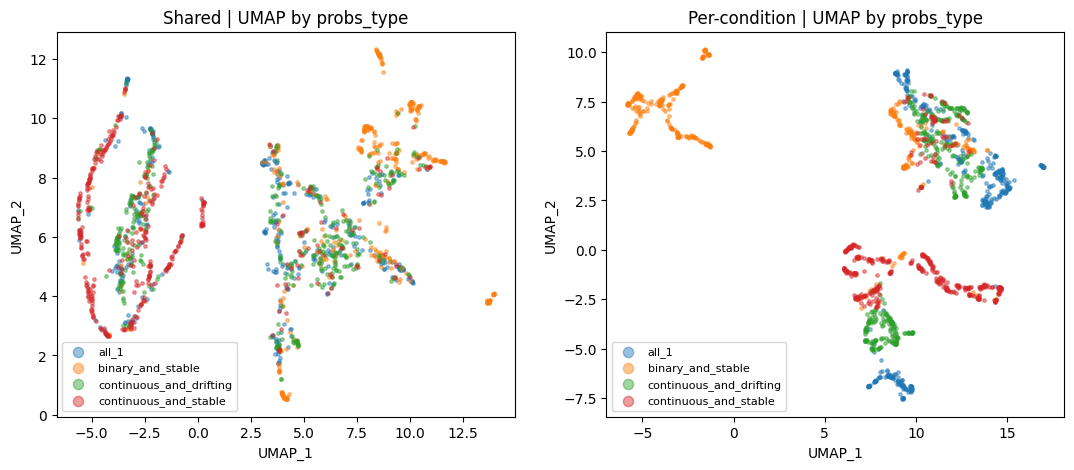

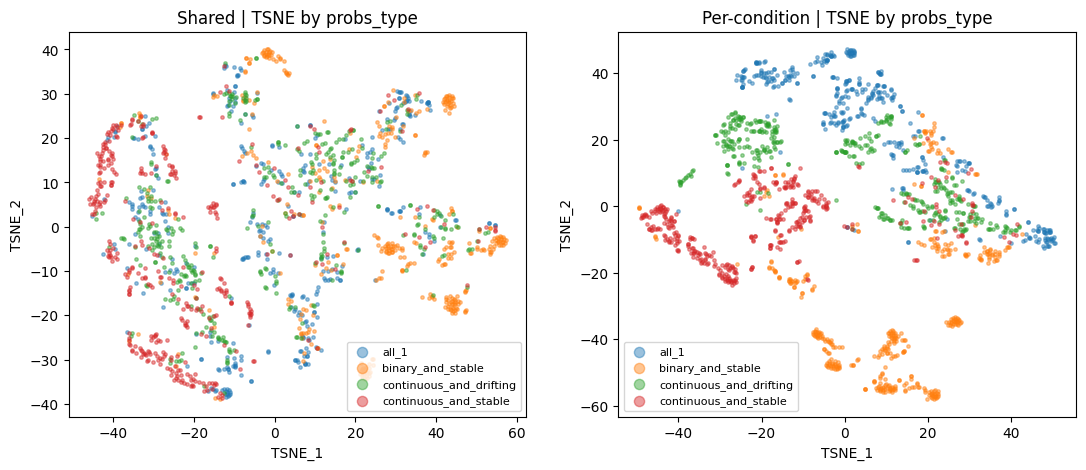

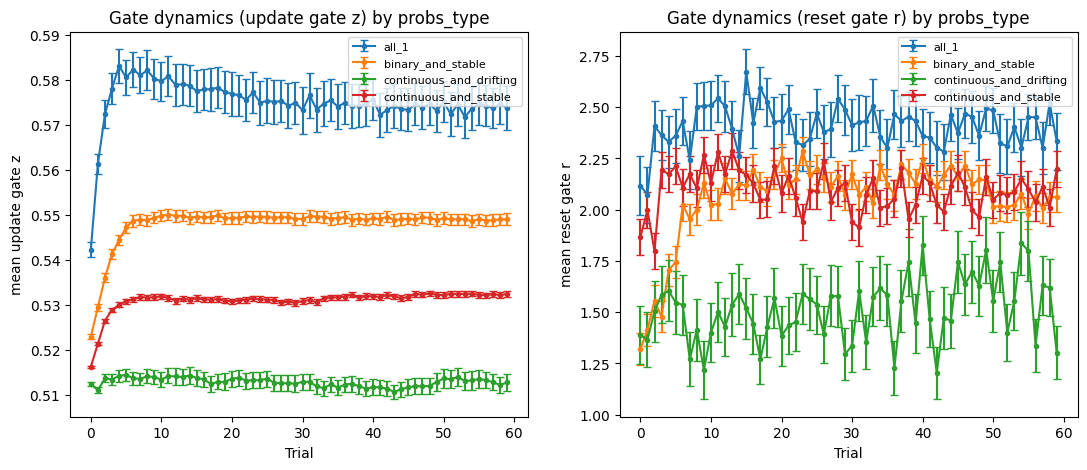

feature: block_change_type
GRU fit complete. Mean NLL/trial: 1.0311
GRU fit complete. Mean NLL/trial: 0.9547
GRU fit complete. Mean NLL/trial: 0.9305
             delta_nll  ci_low  ci_high  cca_top8  transfer
condition                                                  
n_states       -11.171 -14.546   -8.131     0.947     0.498
points_type    -54.505 -67.226  -41.838     0.958     0.374
probs_type     -24.625 -30.325  -19.003     0.950     0.577



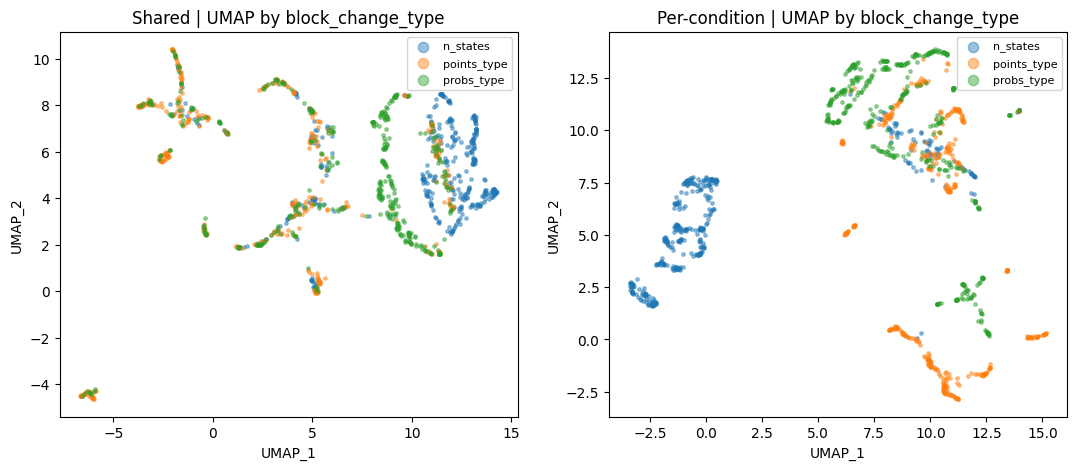

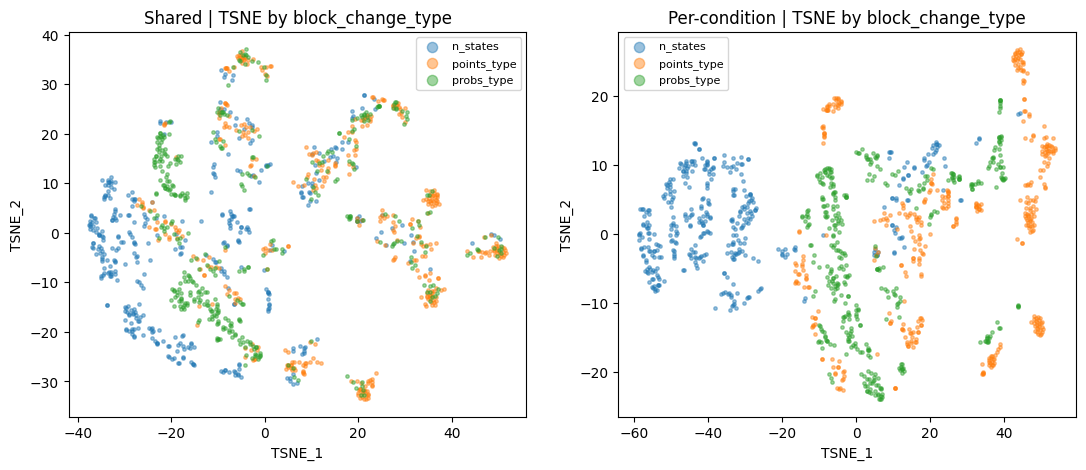

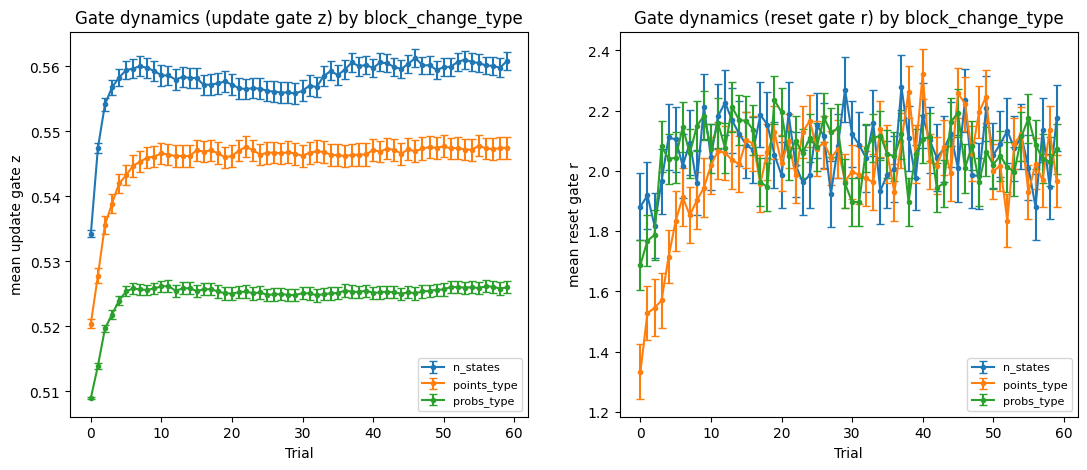

In [48]:
# Scan across features: each feature gets the full per-condition treatment.
scan_features = CONFIG["scan_features"]
scan_results = {}
for feat in scan_features:
    print("=" * 70, flush=True)
    print(f"feature: {feat}", flush=True)
    print("=" * 70, flush=True)
    rep = utils.per_condition_report(
        train_df, val_df, test_df, by=feat, shared_model=gru_model,
        hidden_size=CONFIG["hidden_size"], learning_rate=CONFIG["learning_rate"],
        n_epochs=CONFIG["n_epochs"], batch_size=CONFIG["batch_size"],
        seed=CONFIG["seed"], cap=CONFIG["feature_scan_cap"],
        min_test_sessions=CONFIG["min_test_sessions"],
        max_trials=CONFIG["max_trials"], n_boot=CONFIG["n_boot"],
        embed_methods=CONFIG["embed_methods"],
        n_embed_per_group=CONFIG["n_embed_per_group"],
    )
    scan_results[feat] = rep

    if len(rep["paired_nll"]):
        p = rep["paired_nll"].set_index("condition")
        c = rep["cca"].set_index("condition")
        t = rep["probe_transfer"].set_index("condition")
        out = pd.DataFrame({
            "delta_nll": p["delta_nll_mean"].round(3),
            "ci_low": p["ci_low"].round(3),
            "ci_high": p["ci_high"].round(3),
            "cca_top8": c["cca_mean_top8"].round(3),
            "transfer": t["per_transfer_acc"].round(3),
        })
        print(out.to_string())
        print()

    for method in CONFIG["embed_methods"]:
        emb = rep["embeddings"][method]
        c1 = "PC1" if method == "pca" else f"{method.upper()}_1"
        c2 = "PC2" if method == "pca" else f"{method.upper()}_2"
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        utils.plot_scatter_by_feature(emb["shared"], c1, c2, feat, ax=axes[0],
                                      title=f"Shared | {method.upper()} by {feat}")
        utils.plot_scatter_by_feature(emb["per"], c1, c2, feat, ax=axes[1],
                                      title=f"Per-condition | {method.upper()} by {feat}")
        plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    utils.plot_gate_curves(rep["lat_per_all"], gate="update", feature=feat,
                           max_trials=CONFIG["max_trials"], ax=axes[0])
    utils.plot_gate_curves(rep["lat_per_all"], gate="reset", feature=feat,
                           max_trials=CONFIG["max_trials"], ax=axes[1])
    plt.show()

> 分别训练的模型的解决方案可能有波动，需要多次训练，得到的dynamic才可信